## Set Up

Before running code, type into terminal:
    
    py -3.12 -m venv venv
^this creates the virtual enviornment with Python 3.12

    venv\Scripts\activate
^this activates the virtual environment

    python -m pip install -r requirements.txt
^this installs packages according to the requirements.txt file

In [1]:
from pathlib import Path
from typing import Union, Optional
import copy
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as pltvenv
from matplotlib import axes
import xarray as xr
import pandas as pd
from spotpy.algorithms import _algorithm
import spotpy
import tqdm
from scipy.stats import wasserstein_distance
import dask.array as da
import datetime 
import os
import matplotlib.pyplot as plt #this works for Meghan using version 3.10.7


In [2]:
from hydrus_setup import HydrusSetup
from MS_CUA import MsCua, SensitivityAnalysis, MsCuaAnalyzer

In [3]:
#give path to exe file
exe = os.path.join(os.getcwd(), "H1D_CALC.EXE")

#name the folder files will fill
main_level = os.path.normpath(os.path.join(os.getcwd(), os.pardir))

In [4]:
main_level

'c:\\Users\\x63d979\\Documents\\HydrusCoding\\Hydrus\\DualPerm_GoldCreek-FCP1_20260515_gj'

In [5]:
# Identify file names/paths for input data
input_files = [f for f in os.listdir(os.path.join(main_level, '1_Input',))]

weather_csv = [s for s in input_files if "weather" in s.lower()][0]
irgn_csv = [s for s in input_files if "irrigation" in s.lower()][0]
vg_csv = [s for s in input_files if "vg" in s.lower()][0]
crop_csv = [s for s in input_files if "crop" in s.lower()][0]
gdd_csv = [s for s in input_files if "gdd" in s.lower()][0]
settings_csv = [s for s in input_files if "settings" in s.lower()][0]
calib_obs_csv = [f for f in os.listdir(os.path.join(main_level, '1_Input', 'FieldData', 'CalibrationData'))][0]


In [6]:
# Load and clean observation data
calib_obs = pd.read_csv(os.path.join(main_level, '1_Input', 'FieldData',  'CalibrationData', calib_obs_csv))
calib_obs["Date"] = pd.to_datetime(calib_obs["Date"])

# filter observation data to be contrained by weather data time period (which dictates hydrus output period)
weather_df = pd.read_csv(os.path.join(main_level, '1_Input', weather_csv))
weather_df['Date'] = pd.to_datetime(weather_df['Date'])
calib = calib_obs.loc[(calib_obs['Date'] >= min(weather_df.Date)) & (calib_obs['Date'] <= max(weather_df.Date)), ]

In [7]:
settings = pd.read_csv(os.path.join(main_level, '1_Input', settings_csv))
settings

,FieldDataColumn,Depth_cm,ModelType,ModelOutputColumn,FailValue
0,VWC_6,83,dual_perm,theta84,1
1,SWP,83,dual_perm,h84,10000


In [8]:
def add_gdds(weatherdata, cropdates):
    weatherdata['gdds']=0
    weatherdata['Year']= "NA"

    for i in range(len(weatherdata)):
        weatherdata.loc[i, 'Year'] = weatherdata.Date.dt.year[i]

    weatherdata['Year'] = weatherdata['Year'].astype(int)

    weatherdata = weatherdata.merge(cropdates, on= "Year").rename(columns={'SeedDate': 'StartDate','HarvestDate': 'EndDate'})
    weatherdata["StartDate"] = pd.to_datetime(weatherdata['StartDate'] + "-" + weatherdata['Year'].astype(str))
    weatherdata["EndDate"] = pd.to_datetime(weatherdata['EndDate'] + "-" + weatherdata['Year'].astype(str))
    weatherdata['Date'] = pd.to_datetime(weatherdata['Date'])

    for i in range(1,len(weatherdata)):
        if (weatherdata['Date'][i] >= weatherdata['StartDate'][i] and weatherdata['Date'][i] <= weatherdata['EndDate'][i] and weatherdata['AvgTemp'][i] > 0):
            weatherdata['gdds'][i] = weatherdata['gdds'][i-1] + weatherdata['AvgTemp'][i]
            weatherdata['gdds'][i:len(weatherdata)] = weatherdata['gdds'][i-1] + weatherdata['AvgTemp'][i]
        # reset gdds to 0 at the end of each year
        if (weatherdata['Date'][i] == weatherdata['EndDate'][i]):
            weatherdata['gdds'][i:len(weatherdata)] = 0
    
    return weatherdata

def partition_et(weatherdata, gddinfo):
    
    fallow_coef = gddinfo.loc[gddinfo['Crop'] == 'Fallow']['max.coef']

    weatherdata['t_coef'] = 0
    weatherdata['e_coef'] = 0.22
  
    for i in range(len(weatherdata)):
        crop = weatherdata['Crop'][i]
        max_coef = gddinfo.loc[gddinfo['Crop'] == crop]['max.coef']
        
        check1 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2emergence']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2close']).astype(int))
        check1 = all(check1)

        if check1 == True:
            weatherdata['t_coef'][i] = (weatherdata['gdds'][i] - gddinfo.loc[gddinfo['Crop'] == crop]['gdd2emergence'])*max_coef/(gddinfo.loc[gddinfo['Crop'] == crop]['gdd2close']-gddinfo.loc[gddinfo['Crop'] == crop]['gdd2emergence'])

        check2 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2close']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2mature']).astype(int))
        check2 = all(check2)

        if check2 == True:
            weatherdata['t_coef'][i] = max_coef
        
        check3 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2mature']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['Crop'] == crop]['gdd2harvest']).astype(int))
        check3 = all(check3)

        if check3 == True:
            weatherdata['t_coef'][i] = max_coef-(weatherdata['gdds'][i] - gddinfo.loc[gddinfo['Crop'] == crop]['gdd2mature'])/(gddinfo.loc[gddinfo['Crop'] == crop]['gdd2harvest']-gddinfo.loc[gddinfo['Crop'] == crop]['gdd2mature'])

        check4 = weatherdata['t_coef'][i] <= 0.22
        check4 = bool(check4)

        if check4 == True:
            weatherdata['e_coef'][i] = fallow_coef - weatherdata['t_coef'][i]

        check5 = weatherdata['t_coef'][i] > 0.22
        check5 = bool(check5)
        if check5 == True:
            weatherdata['e_coef'][i] = 0

        weatherdata['pot_t_cm'] = weatherdata['ET_cm']*weatherdata['t_coef']
        weatherdata['pot_e_cm'] = weatherdata['ET_cm']*weatherdata['e_coef']

    return(weatherdata)

def grow_roots_obs(weatherdata, rootobs):
    rootobs['Date'] = pd.to_datetime(rootobs['Date'])
    atmtest= weatherdata
    atmtest['RootDepth'] = 0
    atmtest = atmtest.merge(rootobs, how= 'left', on= 'Date')
    atmtest.loc[np.isnan(atmtest['Depth']) == False, 'RootDepth'] = atmtest.loc[np.isnan(atmtest['Depth']) == False, 'Depth']

    years = list(set(atmtest['Year']))

    for k in range(len(years)):
        
        root_year = atmtest.loc[(atmtest['Year'] == years[k]) & (np.isnan(atmtest['Depth']) == False)]

        rts = {'Growthrate': ["NA"], 'Day1': ["NA"], 'Day2': ["NA"]}
        allroots = pd.DataFrame(rts)

        for i in range(1, len(root_year)):
            growth = root_year.iloc[i]['Depth'] - root_year.iloc[i-1]['Depth']
            time = root_year.iloc[i]['Date'] - root_year.iloc[i-1]['Date']
            time= time.days
            growthrate = growth/time
            day1 = root_year.iloc[i-1]['Date']
            day2 = root_year.iloc[i]['Date']

            minidata = pd.DataFrame({'Growthrate':[growthrate], 'Day1':[day1], 'Day2':[day2]})
            allroots = pd.concat([allroots, minidata], ignore_index=True)

        allroots = allroots[allroots['Growthrate'] != "NA"]
        allroots.loc[allroots['Growthrate'] <  0, 'Growthrate'] = 0

        for i in range(len(allroots)):
            day1 = allroots.iloc[i]['Day1']
            day2 = allroots.iloc[i]['Day2']
            gr = allroots.iloc[i]['Growthrate']

            for j in range(len(atmtest)):
                if (atmtest.iloc[j]['Date'] > day1) & (atmtest.iloc[j]['Date'] < day2):
                    atmtest['RootDepth'][j] = atmtest['RootDepth'][j-1] + gr
    return(atmtest)

def grow_roots_gdd(weatherdata, cropdata):
    atmtest = weatherdata
    atmtest['RootDepth'] = 0

    for i in range(1,len(atmtest)):
        crop = atmtest['Crop'][i]
        max_depth = cropdata.loc[cropdata['Crop'] == crop, 'MaxRootDepth']
        max_depth

        check1 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1 = all(check1)
        if check1 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] + (atmtest['AvgTemp'][i] * 0.0665)

        check1b = (atmtest.iloc[i]['AvgTemp'] < 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1b = all(check1b)
        if check1b == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check2 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] >= max_depth)
        check2 = all(check2)
        if check2 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check3 = (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['EndDate'])
        if check3 == True:
            atmtest['RootDepth'][i] = 0

    return(atmtest)

In [9]:
# load inputs for run_hydrus function
atm = pd.read_csv(os.path.join(main_level, '1_Input', weather_csv))
atm['Date'] = pd.to_datetime(atm['Date'])
days = len(atm['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', irgn_csv))
irrigation['Date'] = pd.to_datetime(irrigation['Date'])
cropdates = pd.read_csv(os.path.join(main_level, '1_Input', crop_csv))
gddinfo = pd.read_csv(os.path.join(main_level, '1_Input', gdd_csv))

cropdates = cropdates.merge(gddinfo, on= "Crop")

atm2 = add_gdds(weatherdata=atm, cropdates=cropdates)
atm3 = partition_et(weatherdata= atm2, gddinfo=gddinfo)
atm4b = grow_roots_gdd(weatherdata= atm3, cropdata=gddinfo)

#merge weather and irrigation and add for a total water input column
allatm = atm4b.join(irrigation.set_index('Date'), on='Date')
allatm.loc[np.isnan(allatm['Irrigation_cm']) == True, 'Irrigation_cm'] = 0
allatm['WaterIn_cm'] = allatm['Precip_cm'] + allatm['Irrigation_cm']

#create new dataframe to manipulate to be exactly what is needed for PHydrus (keeping old version w/ temperature info for now)
atm_hydrus = allatm[['WaterIn_cm', 'pot_e_cm', 'pot_t_cm', 'RootDepth']]

#these are required column names: 'tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT'
atm_hydrus = atm_hydrus.rename(columns={'pot_e_cm':'rSoil', 'WaterIn_cm':'Prec', 'pot_t_cm': 'rRoot'}) #rename columns that are there
atm_hydrus['tAtm'] = range(1,len(atm2)+1)
atm_hydrus['hCritA']= 1000000 #max allowed surface head, this is hydrus default
atm_hydrus['rB']= 0 #bottom flux, is zero for free drainage boundary condition
atm_hydrus['hB']= 0 #groundwater level, is zero if model is not being run with groundwater
atm_hydrus['hT']= 0 #surface pressure head, zero if model uses free drainage

#rearrange to match format input
atm_hydrus = atm_hydrus[['tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT']]

#Observation Nodes
obspts = settings.loc[:, "Depth_cm"]
obspts= obspts*-1
obs = obspts.unique()

#Timestep list 
timesteps2 = [0.001, 0.003, 0.005, 0.006, 0.0001, 0.0003, 0.0004, 0.01, 0.00002,
            0.00003, 0.00004, 0.00005, 0.00006, 0.00007, 0.00009, 0.0002, 0.0007, 0.0009,
            0.0055, 0.0065, 0.00015, 0.00055, 0.00095] #actual good time steps

C:\Users\x63d979\AppData\Local\Temp\ipykernel_28476\858538811.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  weatherdata['gdds'][i] = weatherdata['gdds'][i-1] + weatherdata['AvgTemp'][i]
C:\Users\x63d979\AppData\Local\Temp\ipykernel_28

In [10]:
import datetime
seed = datetime.datetime.strptime(cropdates.loc[0, "SeedDate"], '%d-%b')
harvest = datetime.datetime.strptime(cropdates.loc[0, "HarvestDate"], '%d-%b')
start = datetime.datetime.strptime("1-Jan", '%d-%b')

# trmin (when roots start growing) and trmax (when roots stop growing)
if cropdates.loc[0, "PerennialYN"] == "Y":
    trmin = 1
else:
    trmin = (seed - start).days + 1

trmax = (harvest - start).days + 1

# xrmin (root depth at start of growth) and xrmax (root depth at end of growth)
xrmin = cropdates.loc[0, "MinRootDepth"]
xrmax = cropdates.loc[0, "MaxRootDepth"]

In [11]:
# read model type, structure VGS accordingly (6 for single por, 17 for dual perm)
model_type = settings["ModelType"].loc[0]

if model_type == "dual_perm":
    vg_len = 17
elif model_type == "single_por":
    vg_len = 6

# Format vgs to be an array
vgs = pd.read_csv(os.path.join(main_level, '1_Input', vg_csv)).loc[:, "thetar":]
depths = pd.read_csv(os.path.join(main_level, '1_Input', vg_csv)).loc[:, :"thetar"]
vgs_array = np.array(vgs).reshape(1,len(vgs),vg_len)[0] 
vgs_array

array([[6.91000e-02, 4.23400e-01, 6.10000e-03, 1.57830e+00, 1.46000e+01,
        5.00000e-01, 1.00000e-03, 3.00000e-01, 3.50000e-02, 1.50000e+00,
        1.00000e+02, 5.00000e-01, 5.00000e-02, 2.00000e+00, 4.00000e-01,
        3.00000e+00, 1.50000e-02],
       [5.00000e-02, 3.70000e-01, 3.53000e-02, 3.18000e+00, 6.42980e+02,
        5.00000e-01, 1.03000e-02, 2.60000e-01, 3.36000e-02, 1.39700e+00,
        1.28080e+02, 5.00000e-01, 5.00000e-02, 2.22000e+00, 4.00000e-01,
        4.53900e+00, 1.97546e+00]])

In [12]:
# Identify output columns to keep
calib_cols = settings["ModelOutputColumn"]

# Identify values to use if model fails
fail_vals = settings["FailValue"]

## Testing single forward runs

### Simplest test

INFO: Directory c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250 created
INFO: model.__init__(): Directory c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250 created
INFO: Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250\SELECTOR.IN
INFO: model.write_selector(): Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250\SELECTOR.IN
INFO: Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250\PROFILE.DAT
INFO: model.write_profile(): Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111115257250\PROFILE.DAT
INFO: Successfully wrote c:\Users\x63d979\Documents\Hyd

run complete


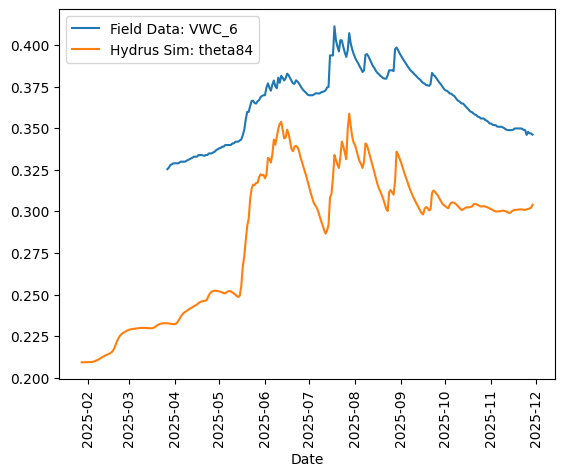

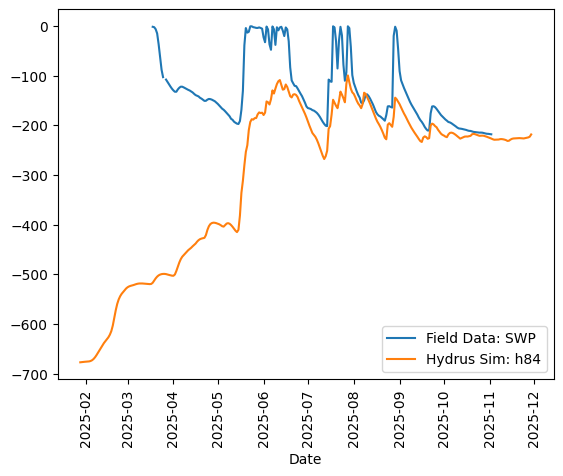

In [13]:
from run_hydrus import run_dual_perm
hydrus_output = run_dual_perm(vgs, depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
                              calib_cols, settings, trmin, trmax, xrmin, xrmax)

i = 0
for x in calib_cols:
    field = settings.loc[settings['ModelOutputColumn'] == x, 'FieldDataColumn'].item()
    plt.figure()
    plt.plot(calib["Date"], calib[field], label="Field Data: " + field)
    plt.plot(calib["Date"], hydrus_output[:,i], label= "Hydrus Sim: " + x)
    plt.xlabel("Date")
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    i = i + 1

In [14]:
# Testing with return_all = True
from run_hydrus import run_dual_perm
alldata = run_dual_perm(vgs, depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
                        calib_cols, settings, trmin, trmax, xrmin, xrmax, return_all=True)
alldata

INFO: Directory c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185 created
INFO: model.__init__(): Directory c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185 created
INFO: Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185\SELECTOR.IN
INFO: model.write_selector(): Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185\SELECTOR.IN
INFO: Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185\PROFILE.DAT
INFO: model.write_profile(): Successfully wrote c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\3_Results\20260618111117293185\PROFILE.DAT
INFO: Successfully wrote c:\Users\x63d979\Documents\Hyd

run complete


,Date,Precip_cm,ET_cm,MinTemp,MaxTemp,AvgTemp,gdds,Year,rTopT,rRootT,...,sum(vTopM),vFrac,sum(vFrac),vBotF,sum(vBotF),vBotM,sum(vBotM),h84,theta84,Flux
0,2022-01-01,0.0000,0.012779,-29.272222,-12.805556,-20.533333,0,2022,0.002811,0.00000,...,0.00253,-0.013060,-0.008537,-0.003806,-0.003673,-0.001346,-0.001346,-149.805,0.3334,-0.502
1,2022-01-02,0.0000,0.071120,-18.911111,-0.700000,-7.688889,0,2022,0.015650,0.00000,...,0.01661,-0.017960,-0.023560,-0.004951,-0.008196,-0.001349,-0.002693,-149.824,0.3334,-0.292
2,2022-01-03,0.1016,0.146198,-8.311111,2.700000,-1.261111,0,2022,-0.069440,0.00000,...,-0.04588,-0.008614,-0.033250,-0.006399,-0.013960,-0.001377,-0.004053,-149.873,0.3334,-0.182
3,2022-01-04,0.0254,0.030048,-10.438889,-1.627778,-5.372222,0,2022,-0.018790,0.00000,...,-0.06279,-0.009563,-0.042890,-0.008544,-0.021580,-0.001698,-0.005553,-150.074,0.3333,-0.130
4,2022-01-05,0.2032,0.020459,-18.038889,-5.877778,-13.761111,0,2022,-0.198700,0.00000,...,-0.24160,0.002698,-0.042780,-0.009931,-0.030960,-0.003738,-0.008188,-150.127,0.3333,-0.117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,2025-12-28,0.0000,0.036143,-18.120000,-4.590000,-10.073125,0,2025,0.000000,0.02799,...,-276.10000,-0.010590,27.250000,-0.011280,-3.392000,-0.049310,-16.120000,-153.236,0.3318,-0.126
1458,2025-12-29,0.0000,0.021340,-9.510000,-0.150000,-5.042708,0,2025,0.000000,0.01652,...,-276.10000,-0.010490,27.250000,-0.011440,-3.404000,-0.056140,-16.180000,-154.199,0.3313,-0.086
1459,2025-12-30,0.0000,0.006405,-10.300000,1.280000,-5.575208,0,2025,0.000000,0.00496,...,-276.10000,-0.007311,27.240000,-0.011490,-3.415000,-0.059170,-16.230000,-155.231,0.3309,-0.052
1460,2025-12-31,0.0000,0.004581,-11.580000,0.280000,-7.343542,0,2025,0.001008,0.00000,...,-276.10000,0.005619,27.230000,-0.011410,-3.427000,-0.059470,-16.290000,-156.047,0.3305,-0.039


In [15]:
alldata.columns
# F is for fractures, T is for matrix; we want T

Index(['Date', 'Precip_cm', 'ET_cm', 'MinTemp', 'MaxTemp', 'AvgTemp', 'gdds',
       'Year', 'rTopT', 'rRootT', 'vTopT', 'vRootT', 'vBotT', 'sum(rTopT)',
       'sum(rRoot)', 'sum(vTopT)', 'sum(vRoot)', 'sum(vBotT)', 'hTop', 'hRoot',
       'hBot', 'vTopF', 'vTopM', 'sum(vTopM)', 'vFrac', 'sum(vFrac)', 'vBotF',
       'sum(vBotF)', 'vBotM', 'sum(vBotM)', 'h84', 'theta84', 'Flux'],
      dtype='object')

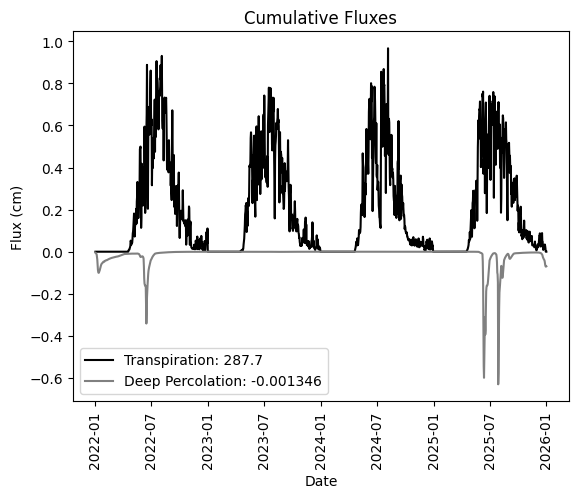

In [16]:
#plot cumulative fluxes 
xs= alldata['Date']

from datetime import datetime
xs = pd.to_datetime(xs)
y1 = alldata['vRootT'] # transpiration
y2= alldata['vBotT'] # deep percolation
#y3= alldata['sum(Evap)'] # evap?
#y4= alldata['sum(vBot)']

#get maxes to include on plot
emax = max(alldata['sum(vRoot)'])
#tmax = max(alldata['sum(?)'])
#dmax = min(alldata['sum(?)'])
rmax = max(alldata['sum(vBotM)'])

#plt.plot(xs, y1, xs, y2, xs, y3, xs, y4)
plt.plot(xs, y1, label= f"Transpiration: {emax}", c= "black")
plt.plot(xs, y2, label= f"Deep Percolation: {rmax}", c= "gray")
#plt.plot(xs, y3, label= f"Runoff: {tmax}", c= "green")
#plt.plot(xs, y4, label= f"Deep Percolation: {dmax}", c= "blue")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Flux (cm)")
plt.title("Cumulative Fluxes")
plt.xticks(rotation= 90)

#plt.savefig(os.path.join(main_level, '3_Results', newfolder, 'Plots', 'CumulativeFluxes.png'))
plt.show()

### run_with_timeout test

Process finished, reading result from file


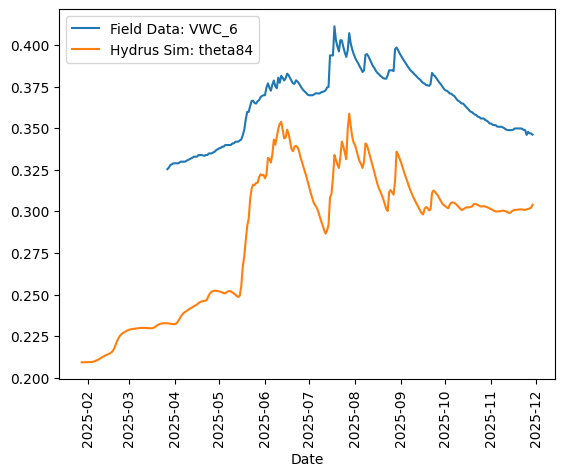

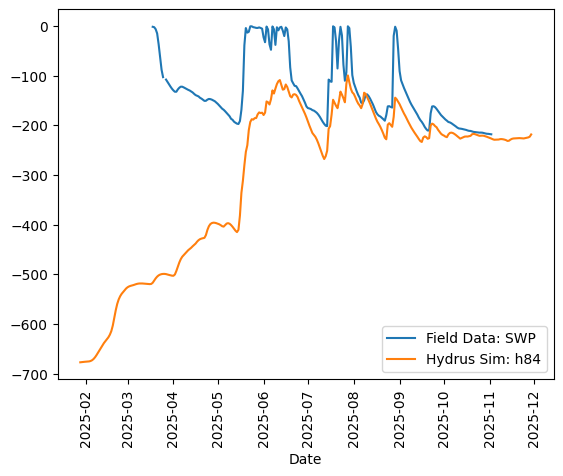

In [17]:
# testing a single converging run (took about 2 sec)
from main import run_with_timeout
import numpy as np

# Failure conditions if timeout
fallback = calib.copy()
for col, val in zip(settings["FieldDataColumn"], settings["FailValue"]):
    fallback[col] = val
fallback = np.array(fallback.drop(columns=["Date"]))

#fallback = np.full((np.array(calib.drop(columns=["Date"])).shape), np.nan)

hydrus_output = run_with_timeout(
    vgs, depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
    calib_cols, settings, trmin, trmax, xrmin, xrmax,
    fallback=fallback,
    timeout=60 
)

#print("Output:\n", hydrus_output)

# plot observed and simulated results at observation node
i = 0
for x in calib_cols:
    field = settings.loc[settings['ModelOutputColumn'] == x, 'FieldDataColumn'].item()
    plt.figure()
    plt.plot(calib["Date"], calib[field], label="Field Data: " + field)
    plt.plot(calib["Date"], hydrus_output[:,i], label= "Hydrus Sim: " + x)
    plt.xlabel("Date")
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    i = i + 1

### hydrus setup test

In [18]:
setup = HydrusSetup(depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
                    calib_cols, settings, trmin, trmax, xrmin, xrmax)
mscua = MsCua(setup, dbname='vg_calibration', dbformat='memory')

In Memory database initialized...


Process finished, reading result from file


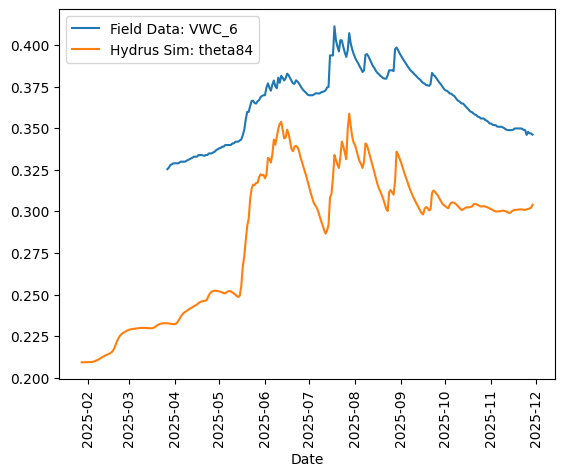

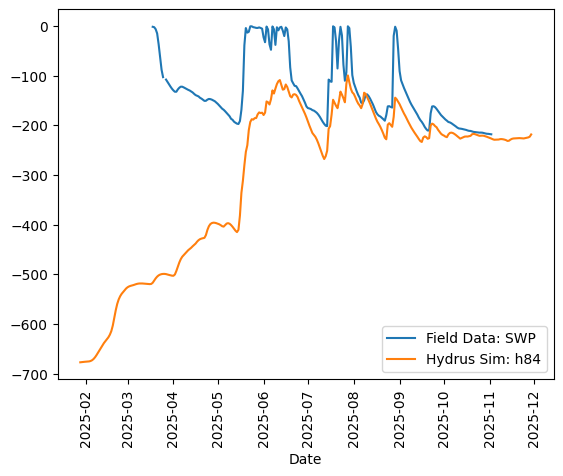

In [19]:
# testing HydrusSetup.simulation()

params = {'thetar': vgs_array[0][0],
          'thetas': vgs_array[0][1],
          'alpha': vgs_array[0][2],
          'n': vgs_array[0][3],
          'ksat': vgs_array[0][4],
          #'l': vgs_array[0][5],
          'thetar_macro': vgs_array[0][6],
          'thetas_macro': vgs_array[0][7],
          'alpha_macro': vgs_array[0][8],
          'n_macro'	: vgs_array[0][9],
          'ksat_macro': vgs_array[0][10],
          #'l_macro': vgs_array[0][11],
          'w': vgs_array[0][12],
          'beta': vgs_array[0][13],
          #'gamma':	vgs_array[0][14],
          'a' : vgs_array[0][15],
          'ka': vgs_array[0][16]
}
hydrus_output = setup.simulation(params)


# plot
i = 0
for x in calib_cols:
    field = settings.loc[settings['ModelOutputColumn'] == x, 'FieldDataColumn'].item()
    plt.figure()
    plt.plot(calib["Date"], calib[field], label="Field Data: " + field)
    plt.plot(calib["Date"], hydrus_output[:,i], label= "Hydrus Sim: " + x)
    plt.xlabel("Date")
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    i = i + 1

In [20]:
def nse_md(observation: np.ndarray, simulation: np.ndarray, return_dict: bool = False, axis=0):
    if observation.shape[axis] == simulation.shape[axis]:
        mean_observed = np.nanmean(observation, axis=axis)
        # compute numerator and denominator
        numerator = np.nansum((observation - simulation) ** 2, axis=axis)
        denominator = np.nansum((observation - mean_observed) ** 2, axis=axis)
        # compute coefficient
        nse = 1 - (numerator / denominator)
        if return_dict:
            return {'nse': nse}
        else:
            return nse
    else:
        raise ValueError("evaluation and simulation data do not have the same length.")

In [21]:
# Calculate NSE for working example
observation = np.array(calib.drop(columns=["Date"]))
nse_md(observation=observation, simulation=hydrus_output)

array([-9.42963237, -5.72673358])

## Sensitivity Analysis

In [ ]:
from MS_CUA import LocalSensitivityAnalysis

setup_sa = HydrusSetup(depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
                       calib_cols, settings, trmin, trmax, xrmin, xrmax)
lsa = LocalSensitivityAnalysis(setup_sa, params, n_samples=5)
results = lsa.sample() 

### Visualizations

In [ ]:
results

In [ ]:
for fig in lsa.plot():
    fig.show()

## Iteration 1

In [23]:
setup1 = HydrusSetup(depths, calib, atm, atm_hydrus, obs, days, timesteps2, 
                     calib_cols, settings, trmin, trmax, xrmin, xrmax)
mscua1 = MsCua(setup1, dbname='vg_calibration', dbformat='memory')
mscua1.sample(reps=30, objfunc_thresholds={'nse': -1000.0})

In Memory database initialized...
Sampling 30 repetitions of the thetar parameter...


Sampling 30 repetitions of the thetas parameter...


Sampling 30 repetitions of the alpha parameter...


Sampling 30 repetitions of the n parameter...


Sampling 30 repetitions of the ksat parameter...


...

simulation:  97%|█████████▋| 29/30 [10:55<00:15, 15.82s/it]

Process finished, reading result from file


Process finished, reading result from file
Evaluating Objective Function Values...
Max number of refined parameter sets: 12
Min number of refined parameter sets: 12
[612 612 612   0 612 612   0   0 612 612 612   0 612 612 612   0 612 612
 612 612 612 612 612 612 612 612   0 612 612 612]
Calculating the 95PPU...
Calculating p- and r-factor metrics...
Max p-factor = 0.4542483660130719
Min p-factor = 0.0
Min r-factor = nan
Max r-factor = nan
1 models had fewer than the minimum allowable refined parameter sets: 25. Either increase the number of samples or exclude these models.
Returning array of failed model indexes.
1 models had a p-factor lower than the allowable minimum: 0.35. Returning array of failed indexes.


c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\2_Code\MS_CUA.py:391: RuntimeWarning: All-NaN slice encountered
  print(f"Min r-factor = {np.nanmin(rfactor)}")
c:\Users\x63d979\Documents\HydrusCoding\Hydrus\DualPerm_GoldCreek-FCP1_20260515_gj\2_Code\MS_CUA.py:392: RuntimeWarning: All-NaN slice encountered
  print(f"Max r-factor = {np.nanmax(rfactor)}")


(array([0], dtype=int64), array([0], dtype=int64))

In [ ]:
# Save iteration 1 results
ds1 = mscua1.database.to_xarray()
ds1.to_netcdf(os.path.join(main_level, "3_Results", "Hydrus_MSCUA_Iteration_1.nc"))

In [ ]:
#ds1 = xr.open_dataset(os.path.join(main_level, "3_Results", "Hydrus_MSCUA_Iteration_1.nc"))

In [ ]:
ds1['thetar_samples']

In [ ]:
# Transform xarray parameters and NSE values into simple csv and save
data = {'thetar' : np.concatenate(ds1['thetar_samples']),
        'thetas' : np.concatenate(ds1['thetas_samples']),
        'alpha' : np.concatenate(ds1['alpha_samples']) ,
        'n' : np.concatenate(ds1['n_samples']) ,
        'ksat' : np.concatenate(ds1['ksat_samples']),
        'l' : np.full(len(ds1.repetition), vgs_array[0][5]),
        'thetar_macro': np.concatenate(ds1['thetar_macro_samples']),
        'thetas_macro': np.concatenate(ds1['thetas_macro_samples']),
        'alpha_macro': np.concatenate(ds1['alpha_macro_samples']),
        'n_macro': np.concatenate(ds1['n_macro_samples']),
        'ksat_macro': np.concatenate(ds1['ksat_macro_samples']),
        'l_macro': np.full(len(ds1.repetition), vgs_array[0][11]),
        'w': np.concatenate(ds1['w_samples']),
        'beta': np.concatenate(ds1['beta_samples']),
        'gamma' : np.full(len(ds1.repetition), vgs_array[0][14]),
        'a': np.concatenate(ds1['a_samples']),
        'ka': np.concatenate(ds1['ka_samples']),
        'nse': np.concatenate(ds1['nse'])
        }
pd.DataFrame(data).to_csv(os.path.join(main_level, '3_Results', 'MSCUA1.csv'))

### Stats

In [ ]:
ds1.best_obj_function

In [ ]:
ds1.best_parameter_set

In [ ]:
ana = MsCuaAnalyzer(ds1)

### Visualizations

In [ ]:
param_names = ['thetar', 'thetas', 'alpha', 'n', 'ksat',
               'thetar_macro', 'thetas_macro', 'alpha_macro', 'n_macro', 'ksat_macro', 
               'w', 'beta', 'a', 'ka']
for name in param_names:
    ana.plot_refined_parameters(param=name, indx=0)

In [ ]:
obsdata = np.array(calib.drop(columns=["Date"]))
ana.plot_ppu(0, best_sim=True, obs_data=obsdata, sort=False)

Or, compare the pre- and post- calibration parameter distributions. Obviously in this case our pre-distribution was just a Uniform distribution for a given range.

In [ ]:
ax = plt.axes()
ax.axvline(ds1.best_parameter_set.sel(objective_functions='nse', parameters='ka', field=1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(ds1.ka_refined.values[:,0]), color='green', label='median of refined distribution')
ax.legend()
ana.compare_parameter_distributions('ka', comp_dstb=ds1.ka_samples[:, 0], indx=0, density=True, ax=ax)

## Iteration 2

In [ ]:
refined = mscua1.database.refined_parameters  # dict of param_name -> array with NaNs
setup2 = HydrusSetup(calib, atm, atm_hydrus, obs, days, timesteps2, params=refined)
mscua2 = MsCua(setup2, dbname='iter2', dbformat='memory')
mscua2.sample(reps=1000, objfunc_thresholds={'nse': -2})

In [ ]:
# Save iteration 2 results
ds2 = mscua2.database.to_xarray()
ds2.to_netcdf(os.path.join(main_level, "3_Results", "Hydrus_MSCUA_Iteration_2.nc"))

In [ ]:
#ds2 = xr.open_dataset(os.path.join(main_level, "3_Results", "Hydrus_MSCUA_Iteration_2.nc"))

In [ ]:
# Transform xarray parameters and NSE values into simple csv and save
data = {'thetar' : np.concatenate(ds2['thetar_samples']),
        'thetas' : np.concatenate(ds2['thetas_samples']),
        'alpha' : np.concatenate(ds2['alpha_samples']) ,
        'n' : np.concatenate(ds2['n_samples']) ,
        'ksat' : np.concatenate(ds2['ksat_samples']),
        'l' : np.full(len(ds2.repetition), vgs_array[0][5]),
        'thetar_macro': np.concatenate(ds2['thetar_macro_samples']),
        'thetas_macro': np.concatenate(ds2['thetas_macro_samples']),
        'alpha_macro': np.concatenate(ds2['alpha_macro_samples']),
        'n_macro': np.concatenate(ds2['n_macro_samples']),
        'ksat_macro': np.concatenate(ds2['ksat_macro_samples']),
        'l_macro': np.full(len(ds2.repetition), vgs_array[0][11]),
        'w': np.concatenate(ds2['w_samples']),
        'beta': np.concatenate(ds2['beta_samples']),
        'gamma' : np.full(len(ds2.repetition), vgs_array[0][14]),
        'a': np.concatenate(ds2['a_samples']),
        'ka': np.concatenate(ds2['ka_samples']),
        'nse': np.concatenate(ds2['nse'])
        }
pd.DataFrame(data).to_csv(os.path.join(main_level, '3_Results', 'MSCUA2.csv'))

### Stats

In [ ]:
ds2.best_obj_function

In [ ]:
ds2.best_parameter_set

### Visualizations

In [ ]:
iter2_ana = MsCuaAnalyzer(ds2)

Compare parameter distributions

In [ ]:
ax = plt.axes()
ax.axvline(ds2.best_parameter_set.sel(objective_functions='nse', parameters='ka', field=1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(ds2.ka_refined.values[:,0]), color='green', label='median of refined distribution')
ax.legend()
iter2_ana.compare_parameter_distributions('ka', comp_dstb=ds1.ka_refined.values[:,0], indx=0, density=True, ax=ax)

In [ ]:
iter2_ana.plot_ppu(0, best_sim=True, obs_data=obsdata, sort=False)